# 02 — EDA & Visualization (VaxFlow)

สำรวจดีมานด์วัคซีน (แนวโน้ม/ฤดูกาล/ความผันผวน) + สถานะคลังระดับขวด 
เพื่อเข้าใจรูปแบบก่อนสร้างฟีเจอร์และพยากรณ์

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
CLEAN = ROOT / 'data' / 'vaccine' / 'clean'
demand = pd.read_csv(CLEAN / 'demand_daily.csv', parse_dates=['date'])
vials = pd.read_csv(CLEAN / 'vaccine_vial_clean.csv', parse_dates=['effective_expiry'])
products = pd.read_csv(CLEAN / 'vaccine_product_clean.csv')
demand.head()

,date,hospital_id,product_id,demand
0,2025-12-28,HOSP_001,VAX_MRNA_01,10
1,2025-12-29,HOSP_001,VAX_MRNA_01,45
2,2025-12-30,HOSP_001,VAX_MRNA_01,38
3,2025-12-31,HOSP_001,VAX_MRNA_01,38
4,2026-01-01,HOSP_001,VAX_MRNA_01,42


## 1) แนวโน้มดีมานด์รวมตามเวลา

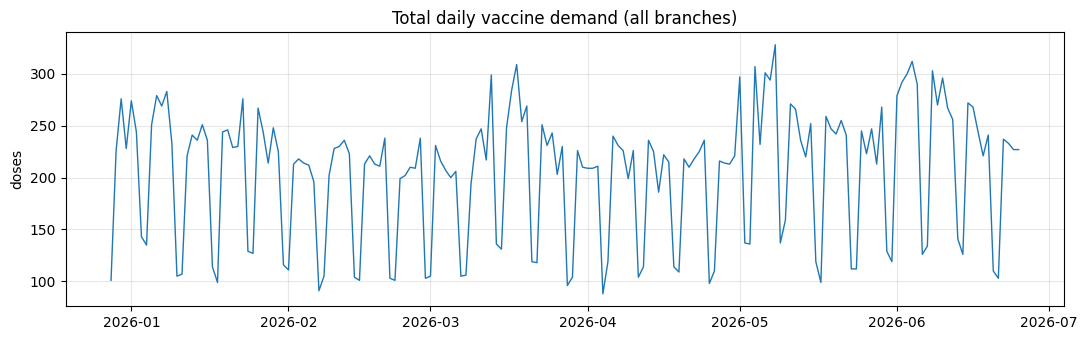

In [2]:
total = demand.groupby('date')['demand'].sum()
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(total.index, total.values, lw=1)
ax.set_title('Total daily vaccine demand (all branches)'); ax.set_ylabel('doses'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2) เทียบรายสาขา + รายผลิตภัณฑ์

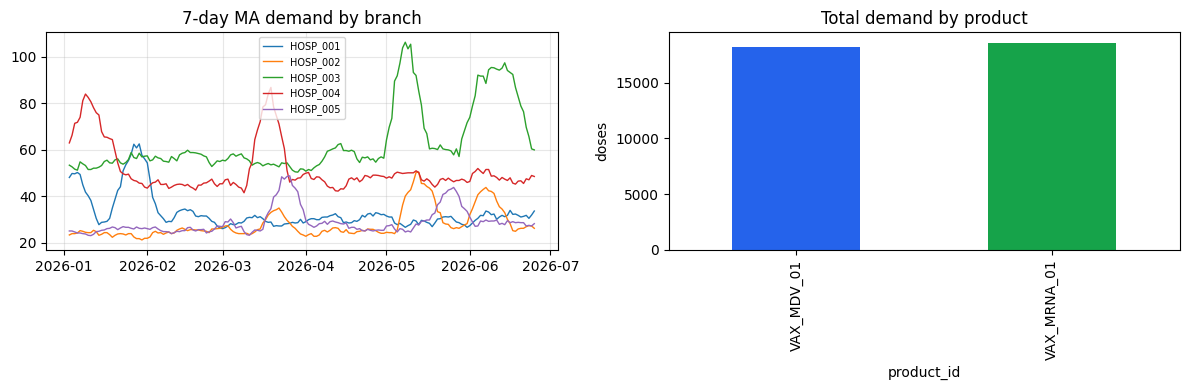

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hid, g in demand.groupby('hospital_id'):
    axes[0].plot(g.groupby('date')['demand'].sum().rolling(7).mean(), label=hid, lw=1)
axes[0].set_title('7-day MA demand by branch'); axes[0].legend(fontsize=7); axes[0].grid(alpha=.3)
demand.groupby('product_id')['demand'].sum().plot.bar(ax=axes[1], color=['#2563eb', '#16a34a'])
axes[1].set_title('Total demand by product'); axes[1].set_ylabel('doses')
plt.tight_layout(); plt.show()

## 3) ฤดูกาลรายสัปดาห์ (weekday effect)

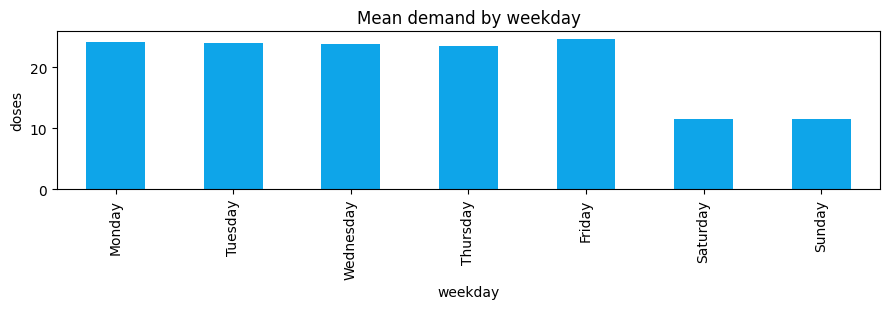

weekday
Monday       24.1
Tuesday      24.0
Wednesday    23.8
Thursday     23.5
Friday       24.7
Saturday     11.5
Sunday       11.5
Name: demand, dtype: float64

In [4]:
demand['weekday'] = demand['date'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_wd = demand.groupby('weekday')['demand'].mean().reindex(order)
fig, ax = plt.subplots(figsize=(9, 3.2))
by_wd.plot.bar(ax=ax, color='#0ea5e9'); ax.set_title('Mean demand by weekday'); ax.set_ylabel('doses')
plt.tight_layout(); plt.show()
by_wd.round(1)

## 4) สถานะคลังระดับขวด — อายุที่เหลือ (Dynamic Shelf-Life)

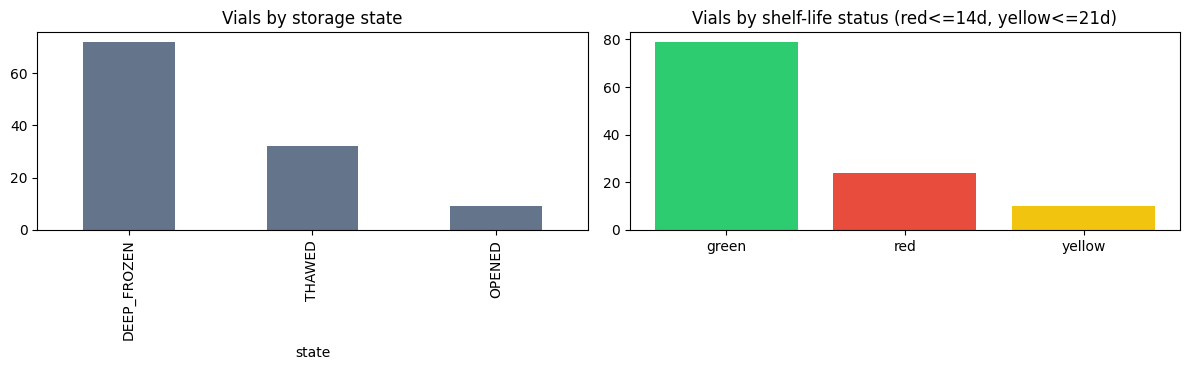

{'green': 79, 'red': 24, 'yellow': 10}


In [5]:
now = pd.Timestamp('2026-06-26T08:00:00+07:00')
vials['effective_expiry'] = pd.to_datetime(vials['effective_expiry'], utc=True, format='ISO8601')
vials['days_remaining'] = (vials['effective_expiry'] - now).dt.total_seconds() / 86400
def status(d):
    return 'red' if d <= 14 else ('yellow' if d <= 21 else 'green')
vials['status'] = vials['days_remaining'].apply(status)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
vials['state'].value_counts().plot.bar(ax=axes[0], color='#64748b')
axes[0].set_title('Vials by storage state')
colors = {'red': '#e74c3c', 'yellow': '#f1c40f', 'green': '#2ecc71'}
sc = vials['status'].value_counts()
axes[1].bar(sc.index, sc.values, color=[colors[s] for s in sc.index])
axes[1].set_title('Vials by shelf-life status (red<=14d, yellow<=21d)')
plt.tight_layout(); plt.show()
print(sc.to_dict())